In [1]:
import torch
from sklearn.datasets import fetch_california_housing
housing = fetch_california_housing()

In [2]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from torch.utils.data import TensorDataset, DataLoader

X = housing['data']
y = housing['target']

X_train_full, X_test, y_train_full, y_test = train_test_split(X,y)
X_train, X_valid, y_train, y_valid = train_test_split(X_train_full,y_train_full)

print(X_train.shape, X_test.shape, X_valid.shape)

scl = StandardScaler()
scl.fit(X_train)

X_train = scl.transform(X_train)
X_test = scl.transform(X_test)
X_valid = scl.transform(X_valid)

X_train = torch.FloatTensor(X_train)
X_test = torch.FloatTensor(X_test)
X_valid = torch.FloatTensor(X_valid)

y_train = torch.FloatTensor(y_train).view(-1,1)
y_test = torch.FloatTensor(y_test).view(-1,1)
y_valid = torch.FloatTensor(y_valid).view(-1,1)

# y_train = torch.tensor(y_train, dtype=torch.float32).view(-1,1)
# y_test = torch.tensor(y_test, dtype=torch.float32).view(-1,1)
# y_valid = torch.tensor(y_valid, dtype=torch.float32).view(-1,1)

train_dataset = TensorDataset(X_train, y_train)
test_dataset = TensorDataset(X_test, y_test)
valid_dataset = TensorDataset(X_valid, y_valid)

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=32)
valid_loader = DataLoader(valid_dataset, batch_size=32)

(11610, 8) (5160, 8) (3870, 8)


In [3]:
import torch.nn as nn
import torchmetrics
import matplotlib.pyplot as plt
import numpy as np

In [4]:
if torch.cuda.is_available():
    device = "cuda"
elif torch.backends.mps.is_available():
    device = "mps"
else:
    device = "cpu"

device

'cpu'

In [5]:
def train(
	model, 
	optimizer, 
	criterion, 
	metric, 
	train_loader, 
	valid_loader, 
	n_epochs,
	clip_grad=False
	):
	history = {
		'loss' : [],
		'train_metric' : [],
		'valid_metric' : [],
	}
	for epoch in range(n_epochs):
		# Training 
		total_loss = 0
		metric.reset()
		for X_batch, y_batch in train_loader:
			X_batch, y_batch = X_batch.to(device), y_batch.to(device)
			model.train()
			y_pred = model(X_batch)
			loss = criterion(y_pred, y_batch)
			total_loss += loss.item()
			loss.backward()
			if clip_grad:
				nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
			optimizer.step()
			# for group in optimizer.param_groups:
			# 	for p in group['params']:
			# 		if p.grad is not None:
			# 			print(f'\t{p.grad.max()}') 
			optimizer.zero_grad()
			metric.update(y_pred, y_batch)
		
		avg_loss = total_loss / len(train_loader)
		history['loss'].append(avg_loss)

		avg_metric_train = metric.compute().item()
		history['train_metric'].append(avg_metric_train)

		# Evaluation 
		model.eval()
		metric.reset()
		with torch.no_grad():
			for X_batch, y_batch in valid_loader:
				X_batch, y_batch = X_batch.to(device), y_batch.to(device)
				y_pred = model(X_batch)
				metric.update(y_pred, y_batch)

		avg_metric_valid = metric.compute().item()
		history['valid_metric'].append(avg_metric_valid)

		print(
			f'Epoch: {epoch+1}/{n_epochs}, '
			+f'Loss: {round(avg_loss,3)}, '
			+f'Train Metric: {round(avg_metric_train,3)}, ' 
			+f'Valid Metric: {round(avg_metric_valid,3)}'
		)

		# if epoch>=2:
		# 	break
	return history

def plot_history(history, n_epochs, metric):
    plt.plot(np.arange(n_epochs) + 1, history['train_metric'], linestyle='--', color='r', marker='.', label='Train')
    plt.plot(np.arange(n_epochs) + 1, history['valid_metric'], linestyle='--', color='b', marker='.', label='Valid')
    plt.legend()
    plt.grid()
    plt.xlabel('Epochs')
    plt.ylabel(f'{metric.__class__.__name__}')
    plt.show()

Problems and solutions:

Vanishing Gradients	
- Better activation functions (ReLU, GELU, etc.)
- Residual Connections
- Batch Normalization
- Weight Initialization (Kaiming/He for ReLU, Xavier/Glorot for tanh,sigmoid)
- Less layers

Exploding Gradients	
- Gradient Clipping
- Batch Normalization
- Weight Initialization
- Regularization (L1, L2)
- Lower learning rate

Oscillation
- Increase batch size
- Lower learning rate
- ReduceLROnPlateau rather than step scheduler
- Nesterov Momentum
- Batch Normalization
- Regularization techniques (L2, Dropout)

Flattening
- Cyclic learning rate
- More layers or neurons
- Data Augmentation
- Regularization techniques (L2, Dropout)
- More data

### gradient clipping

Epoch: 1/30, Loss: 0.665, Train Metric: 0.565, Valid Metric: 0.476
Epoch: 2/30, Loss: 0.449, Train Metric: 0.472, Valid Metric: 0.51
Epoch: 3/30, Loss: 0.423, Train Metric: 0.459, Valid Metric: 0.448
Epoch: 4/30, Loss: 0.402, Train Metric: 0.445, Valid Metric: 0.447
Epoch: 5/30, Loss: 0.387, Train Metric: 0.438, Valid Metric: 0.44
Epoch: 6/30, Loss: 0.38, Train Metric: 0.433, Valid Metric: 0.439
Epoch: 7/30, Loss: 0.368, Train Metric: 0.427, Valid Metric: 0.483
Epoch: 8/30, Loss: 0.365, Train Metric: 0.422, Valid Metric: 0.41
Epoch: 9/30, Loss: 0.354, Train Metric: 0.415, Valid Metric: 0.427
Epoch: 10/30, Loss: 0.347, Train Metric: 0.411, Valid Metric: 0.491
Epoch: 11/30, Loss: 0.345, Train Metric: 0.407, Valid Metric: 0.418
Epoch: 12/30, Loss: 0.336, Train Metric: 0.403, Valid Metric: 0.429
Epoch: 13/30, Loss: 0.33, Train Metric: 0.401, Valid Metric: 0.403
Epoch: 14/30, Loss: 0.33, Train Metric: 0.397, Valid Metric: 0.452
Epoch: 15/30, Loss: 0.327, Train Metric: 0.394, Valid Metric: 0

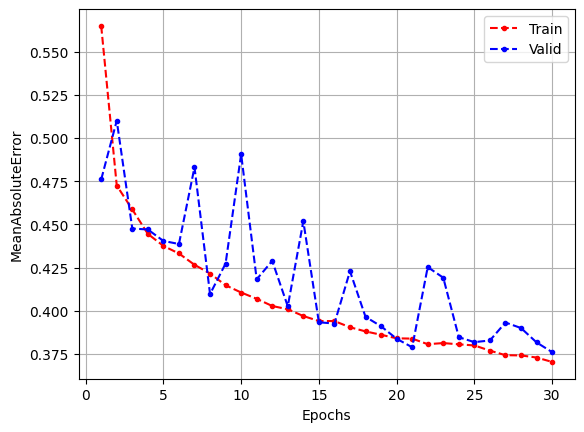

In [ ]:
learning_rate = 0.1
n_epochs=30

model = nn.Sequential(
	nn.Linear(in_features=8, out_features=30), 
	nn.LeakyReLU(),
	nn.Linear(in_features=30, out_features=50), 
	nn.LeakyReLU(),
	nn.Linear(in_features=50, out_features=1),
).to(device)

criterion = nn.MSELoss()
optimizer = torch.optim.SGD(params=model.parameters(), lr=learning_rate)
metric = torchmetrics.MeanAbsoluteError().to(device)

history = train(
    model, 
	optimizer, 
	criterion, 
	metric, 
	train_loader, 
	valid_loader, 
	n_epochs, 
    clip_grad=True # activate gradient clipping
    )
plot_history(history, n_epochs, metric)

### l2 regularization

Epoch: 1/30, Loss: 0.622, Train Metric: 0.553, Valid Metric: 0.469
Epoch: 2/30, Loss: 0.435, Train Metric: 0.468, Valid Metric: 0.478
Epoch: 3/30, Loss: 0.406, Train Metric: 0.451, Valid Metric: 0.449
Epoch: 4/30, Loss: 0.388, Train Metric: 0.439, Valid Metric: 0.46
Epoch: 5/30, Loss: 0.378, Train Metric: 0.431, Valid Metric: 0.431
Epoch: 6/30, Loss: 0.361, Train Metric: 0.42, Valid Metric: 0.426
Epoch: 7/30, Loss: 0.357, Train Metric: 0.418, Valid Metric: 0.436
Epoch: 8/30, Loss: 0.348, Train Metric: 0.412, Valid Metric: 0.428
Epoch: 9/30, Loss: 0.346, Train Metric: 0.407, Valid Metric: 0.406
Epoch: 10/30, Loss: 0.34, Train Metric: 0.403, Valid Metric: 0.412
Epoch: 11/30, Loss: 0.334, Train Metric: 0.399, Valid Metric: 0.395
Epoch: 12/30, Loss: 0.33, Train Metric: 0.397, Valid Metric: 0.419
Epoch: 13/30, Loss: 0.325, Train Metric: 0.392, Valid Metric: 0.382
Epoch: 14/30, Loss: 0.351, Train Metric: 0.392, Valid Metric: 0.394
Epoch: 15/30, Loss: 0.319, Train Metric: 0.388, Valid Metric:

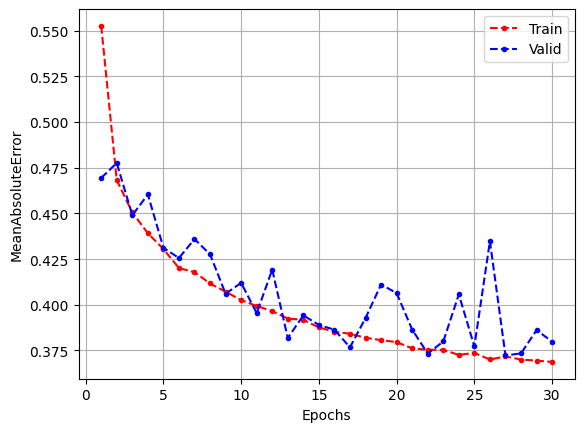

In [78]:
learning_rate = 0.1
n_epochs=30

model = nn.Sequential(
	nn.Linear(in_features=8, out_features=30), 
	nn.LeakyReLU(),
	nn.Linear(in_features=30, out_features=50), 
	nn.LeakyReLU(),
	nn.Linear(in_features=50, out_features=1),
).to(device)

criterion = nn.MSELoss()
optimizer = torch.optim.SGD(params=model.parameters(), lr=learning_rate, weight_decay=1e-4)
metric = torchmetrics.MeanAbsoluteError().to(device)

history = train(
    model, 
	optimizer, 
	criterion, 
	metric, 
	train_loader, 
	valid_loader, 
	n_epochs, 
    clip_grad=True # activate gradient clipping
    )
plot_history(history, n_epochs, metric)

### activation functions + initialization

to prevent exploding gradient:

- reduce learning rate

Epoch: 1/30, Loss: 0.792, Train Metric: 0.617, Valid Metric: 0.514
Epoch: 2/30, Loss: 0.602, Train Metric: 0.515, Valid Metric: 0.474
Epoch: 3/30, Loss: 0.466, Train Metric: 0.481, Valid Metric: 0.451
Epoch: 4/30, Loss: 0.418, Train Metric: 0.46, Valid Metric: 0.448
Epoch: 5/30, Loss: 0.418, Train Metric: 0.447, Valid Metric: 0.472
Epoch: 6/30, Loss: 0.381, Train Metric: 0.436, Valid Metric: 0.422
Epoch: 7/30, Loss: 0.408, Train Metric: 0.425, Valid Metric: 0.438
Epoch: 8/30, Loss: 0.356, Train Metric: 0.419, Valid Metric: 0.429
Epoch: 9/30, Loss: 0.38, Train Metric: 0.417, Valid Metric: 0.402
Epoch: 10/30, Loss: 0.347, Train Metric: 0.409, Valid Metric: 0.42
Epoch: 11/30, Loss: 0.338, Train Metric: 0.406, Valid Metric: 0.457
Epoch: 12/30, Loss: 0.417, Train Metric: 0.405, Valid Metric: 0.399
Epoch: 13/30, Loss: 0.391, Train Metric: 0.404, Valid Metric: 0.391
Epoch: 14/30, Loss: 0.338, Train Metric: 0.397, Valid Metric: 0.396
Epoch: 15/30, Loss: 0.328, Train Metric: 0.396, Valid Metric

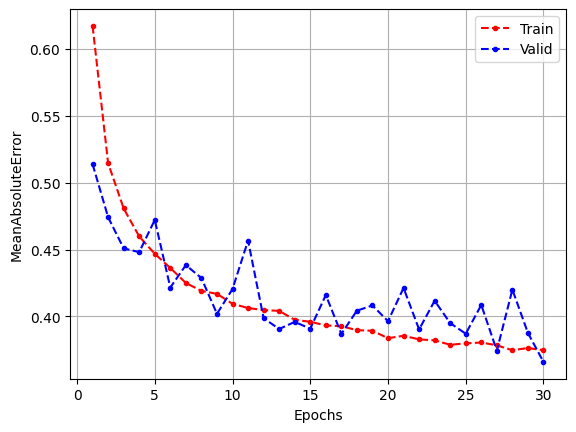

In [74]:
learning_rate = 0.1
n_epochs=30

model = nn.Sequential(
	nn.Linear(in_features=8, out_features=30), 
	nn.LeakyReLU(),
	nn.Linear(in_features=30, out_features=50), 
	nn.LeakyReLU(),
	nn.Linear(in_features=50, out_features=1),
).to(device)

def use_he_init(module):
    if isinstance(module, nn.Linear):
        nn.init.kaiming_uniform_(module.weight, nonlinearity='leaky_relu')
        nn.init.zeros_(module.bias)
model.apply(use_he_init)

criterion = nn.MSELoss()
optimizer = torch.optim.SGD(params=model.parameters(), lr=learning_rate)
metric = torchmetrics.MeanAbsoluteError().to(device)

history = train(
    model, 
	optimizer, 
	criterion, 
	metric, 
	train_loader, 
	valid_loader, 
	n_epochs, 
	clip_grad=True
	)
plot_history(history, n_epochs, metric)

### Batch Normalization

to prevent the wiggle:

- increase batch size
- play with batch norm momentum
- learning rate decay with scheduler
- weight decay

Epoch: 1/30, Loss: 0.684, Train Metric: 0.6, Valid Metric: 0.621
Epoch: 2/30, Loss: 0.498, Train Metric: 0.52, Valid Metric: 0.479
Epoch: 3/30, Loss: 0.476, Train Metric: 0.504, Valid Metric: 0.467
Epoch: 4/30, Loss: 0.445, Train Metric: 0.482, Valid Metric: 0.475
Epoch: 5/30, Loss: 0.45, Train Metric: 0.485, Valid Metric: 0.497
Epoch: 6/30, Loss: 0.424, Train Metric: 0.47, Valid Metric: 0.454
Epoch: 7/30, Loss: 0.426, Train Metric: 0.471, Valid Metric: 0.436
Epoch: 8/30, Loss: 0.428, Train Metric: 0.474, Valid Metric: 0.411
Epoch: 9/30, Loss: 0.416, Train Metric: 0.462, Valid Metric: 0.41
Epoch: 10/30, Loss: 0.418, Train Metric: 0.464, Valid Metric: 0.414
Epoch: 11/30, Loss: 0.406, Train Metric: 0.457, Valid Metric: 0.405
Epoch: 12/30, Loss: 0.419, Train Metric: 0.465, Valid Metric: 0.44
Epoch: 13/30, Loss: 0.416, Train Metric: 0.465, Valid Metric: 0.446
Epoch: 14/30, Loss: 0.404, Train Metric: 0.454, Valid Metric: 0.423
Epoch: 15/30, Loss: 0.396, Train Metric: 0.45, Valid Metric: 0.4

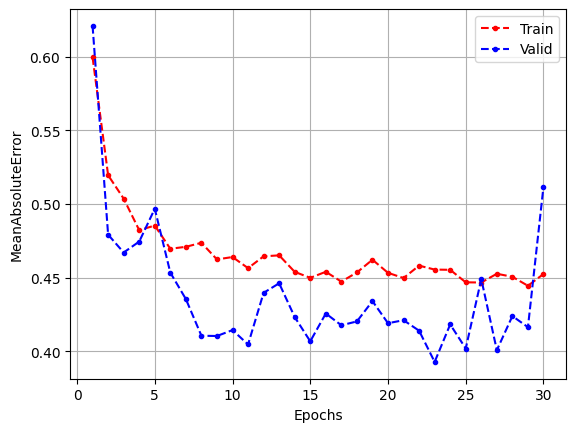

In [79]:
learning_rate = 0.1
n_epochs=30

model = nn.Sequential(
	nn.BatchNorm1d(8),
	nn.Linear(in_features=8, out_features=30), 
	nn.LeakyReLU(),
	nn.BatchNorm1d(30),
	nn.Linear(in_features=30, out_features=50), 
	nn.LeakyReLU(),
	nn.BatchNorm1d(50),
	nn.Linear(in_features=50, out_features=1),
).to(device)

# class PriceRegressor(nn.Module):
# 	def __init__(self, n_features):
# 		super().__init__()
# 		self.sequential = nn.Sequential(
# 			nn.Linear(in_features=n_features, out_features=30, bias=False), 
# 			nn.BatchNorm1d(30),
# 			nn.LeakyReLU(),
# 			nn.Linear(in_features=30, out_features=50, bias=False), 
# 			nn.BatchNorm1d(50),
# 			nn.LeakyReLU(),
# 			nn.Linear(in_features=50, out_features=1),
# 		)
        
# 	def forward(self, X):
# 		y = self.sequential(X)
# 		return y
# model = PriceRegressor(8).to(device)


def use_he_init(module):
    if isinstance(module, nn.Linear):
        nn.init.kaiming_uniform_(module.weight, nonlinearity='leaky_relu')
        nn.init.zeros_(module.bias) # comment if bias=False in Linear layers
model.apply(use_he_init)

criterion = nn.MSELoss()
optimizer = torch.optim.SGD(params=model.parameters(), lr=learning_rate, weight_decay=1e-4)
metric = torchmetrics.MeanAbsoluteError().to(device)

history = train(
	model, 
	optimizer, 
	criterion, 
	metric, 
	train_loader, 
	valid_loader, 
	n_epochs)
plot_history(history, n_epochs, metric)

### optimizers

Epoch: 1/30, Loss: 0.628, Train Metric: 0.575, Valid Metric: 0.532
Epoch: 2/30, Loss: 0.481, Train Metric: 0.507, Valid Metric: 0.519
Epoch: 3/30, Loss: 0.467, Train Metric: 0.494, Valid Metric: 0.401
Epoch: 4/30, Loss: 0.472, Train Metric: 0.496, Valid Metric: 0.514
Epoch: 5/30, Loss: 0.463, Train Metric: 0.495, Valid Metric: 0.498
Epoch: 6/30, Loss: 0.466, Train Metric: 0.497, Valid Metric: 0.465
Epoch: 7/30, Loss: 0.467, Train Metric: 0.497, Valid Metric: 0.516
Epoch: 8/30, Loss: 0.457, Train Metric: 0.493, Valid Metric: 0.415
Epoch: 9/30, Loss: 0.44, Train Metric: 0.483, Valid Metric: 0.495
Epoch: 10/30, Loss: 0.448, Train Metric: 0.489, Valid Metric: 0.414
Epoch: 11/30, Loss: 0.442, Train Metric: 0.483, Valid Metric: 0.547
Epoch: 12/30, Loss: 0.469, Train Metric: 0.5, Valid Metric: 0.468
Epoch: 13/30, Loss: 0.447, Train Metric: 0.488, Valid Metric: 0.508
Epoch: 14/30, Loss: 0.455, Train Metric: 0.493, Valid Metric: 0.505
Epoch: 15/30, Loss: 0.464, Train Metric: 0.498, Valid Metric

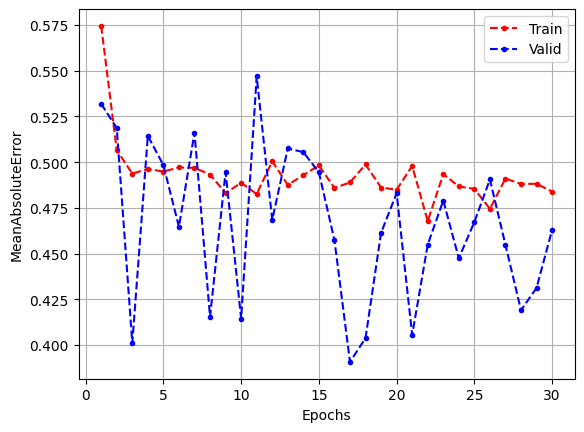

In [37]:
n_epochs=30

model = nn.Sequential(
    nn.BatchNorm1d(8),
	nn.Linear(in_features=8, out_features=30), 
	nn.LeakyReLU(),
    nn.BatchNorm1d(30),
	nn.Linear(in_features=30, out_features=50), 
	nn.LeakyReLU(),
    nn.BatchNorm1d(50),
	nn.Linear(in_features=50, out_features=1),
).to(device)

# class PriceRegressor(nn.Module):
# 	def __init__(self, n_features):
# 		super().__init__()
# 		self.sequential = nn.Sequential(
# 			nn.Linear(in_features=8, out_features=30, bias=False), 
# 			nn.BatchNorm1d(30),
# 			nn.LeakyReLU(),
# 			nn.Linear(in_features=30, out_features=50, bias=False), 
# 			nn.BatchNorm1d(50),
# 			nn.LeakyReLU(),
# 			nn.Linear(in_features=50, out_features=1),
# 		)
        
# 	def forward(self, X):
# 		y = self.sequential(X)
# 		return y
# model = PriceRegressor(n_features=8).to(device)


def use_he_init(module):
    if isinstance(module, nn.Linear):
        nn.init.kaiming_uniform_(module.weight, nonlinearity='leaky_relu')
        nn.init.zeros_(module.bias)
model.apply(use_he_init)

criterion = nn.MSELoss()
# optimizer = torch.optim.SGD(model.parameters(), momentum=0.9, nesterov=True, lr=0.05)
# optimizer = torch.optim.Adagrad(model.parameters(), lr=0.05)
# optimizer = torch.optim.RMSprop(model.parameters(), alpha=0.9, lr=0.05)
optimizer = torch.optim.Adam(model.parameters(), betas=(0.9, 0.999), lr=0.05)
# optimizer = torch.optim.Adamax(model.parameters(), betas=(0.9, 0.999), lr=0.05)
# optimizer = torch.optim.NAdam(model.parameters(), betas=(0.9, 0.999), lr=0.05)
# optimizer = torch.optim.AdamW(model.parameters(), betas=(0.9, 0.999), weight_decay=1e-5, lr=0.05)
metric = torchmetrics.MeanAbsoluteError().to(device)

history = train(model, optimizer, criterion, metric, train_loader, valid_loader, n_epochs)
plot_history(history, n_epochs, metric)

### scheduling

In [9]:
def train_with_scheduler(model, 
	optimizer, 
	criterion, 
	metric, 
	train_loader, 
	valid_loader, 
	n_epochs, 
	warmup_scheduler, 
	scheduler, 
	clip_grad=False
	):
	history = {
		'loss' : [],
		'train_metric' : [],
		'valid_metric' : [],
	}
	for epoch in range(n_epochs):
		warmup_scheduler.step()

		# Training 
		losses = []
		metric.reset()

		for X_batch, y_batch in train_loader:
			X_batch, y_batch = X_batch.to(device), y_batch.to(device)
			model.train()
			y_pred = model(X_batch)
			loss = criterion(y_pred, y_batch)
			losses.append(loss.item())
			loss.backward()
			if clip_grad:
				nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
			optimizer.step()
			optimizer.zero_grad()
			metric.update(y_pred, y_batch)
		
		avg_loss = np.mean(losses)
		history['loss'].append(avg_loss)

		avg_metric_train = metric.compute().item()
		history['train_metric'].append(avg_metric_train)

		# Evaluation 
		model.eval()
		metric.reset()
		with torch.no_grad():
			for X_batch, y_batch in valid_loader:
				X_batch, y_batch = X_batch.to(device), y_batch.to(device)
				y_pred = model(X_batch)
				metric.update(y_pred, y_batch)

		avg_metric_valid = metric.compute().item()
		history['valid_metric'].append(avg_metric_valid)

		print(
			f'Epoch: {epoch+1}/{n_epochs}, '
			+f'Loss: {round(avg_loss,3)}, '
			+f'Train Metric: {round(avg_metric_train,3)}, ' 
			+f'Valid Metric: {round(avg_metric_valid,3)}'
		)

		# scheduling
		if epoch >= 3:
			if isinstance(scheduler, torch.optim.lr_scheduler.ReduceLROnPlateau):
				scheduler.step(avg_metric_valid)
			else:
				scheduler.step()
			print(f"Learning rate: {scheduler.get_last_lr()[0]:.5f}")

		# if epoch>=2:
		# 	break
	return history

C:\Users\user\AppData\Local\Temp\ipykernel_14932\3788781919.py:18: UserWarning: Detected call of `lr_scheduler.step()` before `optimizer.step()`. In PyTorch 1.1.0 and later, you should call them in the opposite order: `optimizer.step()` before `lr_scheduler.step()`.  Failure to do this will result in PyTorch skipping the first value of the learning rate schedule. See more details at https://pytorch.org/docs/stable/optim.html#how-to-adjust-learning-rate
  warmup_scheduler.step()


Epoch: 1/30, Loss: 0.62, Train Metric: 0.572, Valid Metric: 0.628
Epoch: 2/30, Loss: 0.474, Train Metric: 0.501, Valid Metric: 0.481
Epoch: 3/30, Loss: 0.484, Train Metric: 0.506, Valid Metric: 0.457
Epoch: 4/30, Loss: 0.472, Train Metric: 0.503, Valid Metric: 0.49
Learning rate: 0.04500
Epoch: 5/30, Loss: 0.439, Train Metric: 0.48, Valid Metric: 0.475
Learning rate: 0.04050
Epoch: 6/30, Loss: 0.438, Train Metric: 0.481, Valid Metric: 0.628
Learning rate: 0.03645
Epoch: 7/30, Loss: 0.427, Train Metric: 0.473, Valid Metric: 0.437
Learning rate: 0.03281
Epoch: 8/30, Loss: 0.419, Train Metric: 0.469, Valid Metric: 0.445
Learning rate: 0.02952
Epoch: 9/30, Loss: 0.411, Train Metric: 0.462, Valid Metric: 0.427
Learning rate: 0.02657
Epoch: 10/30, Loss: 0.405, Train Metric: 0.46, Valid Metric: 0.449
Learning rate: 0.02391
Epoch: 11/30, Loss: 0.402, Train Metric: 0.458, Valid Metric: 0.444
Learning rate: 0.02152
Epoch: 12/30, Loss: 0.39, Train Metric: 0.451, Valid Metric: 0.464
Learning rate:

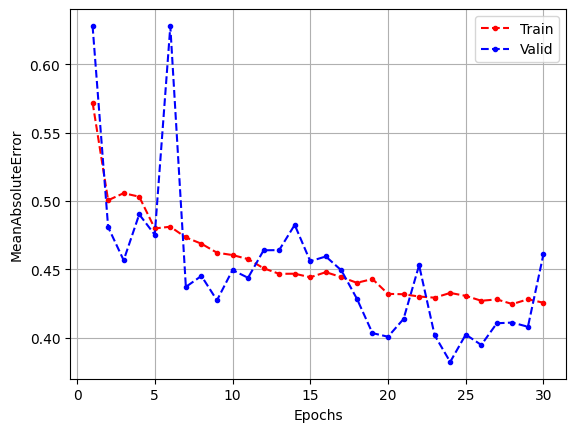

In [10]:
n_epochs=30

# model
model = nn.Sequential(
    nn.BatchNorm1d(8),
	nn.Linear(in_features=8, out_features=30), 
	nn.LeakyReLU(),
    nn.BatchNorm1d(30),
	nn.Linear(in_features=30, out_features=50), 
	nn.LeakyReLU(),
    nn.BatchNorm1d(50),
	nn.Linear(in_features=50, out_features=1),
).to(device)

def use_he_init(module):
    if isinstance(module, nn.Linear):
        nn.init.kaiming_uniform_(module.weight, nonlinearity='leaky_relu')
        nn.init.zeros_(module.bias)
model.apply(use_he_init)

# setup
criterion = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), betas=(0.9, 0.999), lr=0.05)
warmup_scheduler = torch.optim.lr_scheduler.LinearLR(optimizer, start_factor=0.1, end_factor=1.0, total_iters=3)
# warmup_scheduler = torch.optim.lr_scheduler.LambdaLR(optimizer, lambda epoch: (min(epoch, 3) / 3) * (1.0 - 0.1) + 0.1)
scheduler = torch.optim.lr_scheduler.ExponentialLR(optimizer, gamma=0.9)
# scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode="max", patience=2, factor=0.1)
metric = torchmetrics.MeanAbsoluteError().to(device)

# train
history = train_with_scheduler(
    model, 
	optimizer, 
	criterion, 
	metric, 
	train_loader, 
	valid_loader, 
	n_epochs, 
	warmup_scheduler, 
    scheduler
    )
plot_history(history, n_epochs, metric)

### dropout 

Epoch: 1/40, Loss: 0.905, Train Metric: 0.667, Valid Metric: 0.534
Epoch: 2/40, Loss: 0.593, Train Metric: 0.558, Valid Metric: 0.583
Epoch: 3/40, Loss: 0.556, Train Metric: 0.545, Valid Metric: 0.562
Epoch: 4/40, Loss: 0.607, Train Metric: 0.535, Valid Metric: 0.475
Epoch: 5/40, Loss: 0.597, Train Metric: 0.534, Valid Metric: 0.516
Epoch: 6/40, Loss: 0.552, Train Metric: 0.531, Valid Metric: 0.535
Epoch: 7/40, Loss: 0.546, Train Metric: 0.526, Valid Metric: 0.463
Epoch: 8/40, Loss: 0.516, Train Metric: 0.522, Valid Metric: 0.486
Epoch: 9/40, Loss: 0.523, Train Metric: 0.531, Valid Metric: 0.47
Epoch: 10/40, Loss: 0.709, Train Metric: 0.526, Valid Metric: 0.515
Epoch: 11/40, Loss: 0.529, Train Metric: 0.526, Valid Metric: 0.624
Epoch: 12/40, Loss: 0.498, Train Metric: 0.52, Valid Metric: 0.509
Epoch: 13/40, Loss: 0.501, Train Metric: 0.517, Valid Metric: 0.614
Epoch: 14/40, Loss: 0.54, Train Metric: 0.521, Valid Metric: 0.55
Epoch: 15/40, Loss: 0.507, Train Metric: 0.519, Valid Metric:

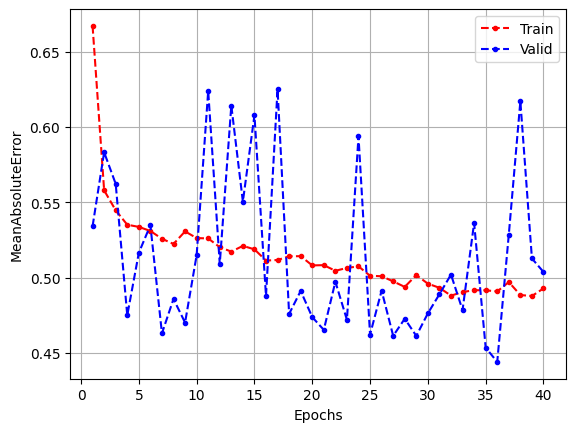

In [25]:
learning_rate = 0.5
n_epochs=40

model = nn.Sequential(
	nn.Linear(in_features=8, out_features=30), 
	nn.LeakyReLU(),
    nn.Dropout(p=0.2),
	nn.Linear(in_features=30, out_features=50), 
	nn.LeakyReLU(),
    nn.Dropout(p=0.2),
	nn.Linear(in_features=50, out_features=1),
).to(device)

# class PriceRegressor(nn.Module):
# 	def __init__(self, n_features):
# 		super().__init__()
# 		self.sequential = nn.Sequential(
# 			nn.Linear(in_features=8, out_features=30), 
# 			nn.LeakyReLU(),
# 			nn.Dropout(p=0.2),
# 			nn.Linear(in_features=30, out_features=50), 
# 			nn.LeakyReLU(),
# 			nn.Dropout(p=0.2),
# 			nn.Linear(in_features=50, out_features=1),
# 		)
        
# 	def forward(self, X):
# 		y = self.sequential(X)
# 		return y
# model = PriceRegressor(n_features=8).to(device)


def use_he_init(module):
    if isinstance(module, nn.Linear):
        nn.init.kaiming_uniform_(module.weight, nonlinearity='leaky_relu')
        nn.init.zeros_(module.bias)
model.apply(use_he_init)

criterion = nn.MSELoss()
optimizer = torch.optim.SGD(params=model.parameters(), lr=learning_rate)
metric = torchmetrics.MeanAbsoluteError().to(device)

history = train(
    model, 
	optimizer, 
	criterion, 
	metric, 
	train_loader, 
	valid_loader, 
	n_epochs, 
    clip_grad=True
	)
plot_history(history, n_epochs, metric)

### monte carlo dropout

In [26]:
model.eval()
for module in model.modules():
    if isinstance(module, nn.Dropout):
        module.train()

X_new, y_new = test_loader.dataset[:3]
X_new, y_new = X_new.to(device), y_new.to(device)

with torch.no_grad():
    X_new_repeated = X_new.repeat_interleave(100, dim=0) # torch.Size([300, 8])
    y_pred = model(X_new_repeated).reshape(3, 100)
    # y_probas_all = torch.nn.functional.softmax(y_logits_all, dim=-1)
    # y_probas = y_probas_all.mean(dim=1)

In [28]:
y_pred.mean(dim=1)

tensor([2.6334, 2.6971, 2.0273])

In [29]:
y_new

tensor([[3.1270],
        [2.6130],
        [2.7430]])